# Motif-Context Swap Experiment

Isolate motif syntax (MoDISco-annotated regions) from context (non-motif regions),
create chimeric sequences by swapping motif syntaxes into different contexts across
activity bins, predict with LegNet, and plot results.

In [1]:
"""Cell 1: Load data, extract seqlet annotations, merge overlapping intervals."""
import os
import sys
import numpy as np
import pandas as pd
import h5py
from pathlib import Path

BASE_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap'
FG_DIR = f'{BASE_DIR}/data/foregrounds'
MUT_DIR = f'{BASE_DIR}/data/mutagenesis_lib'
ACTIVITY_CSV = f'{BASE_DIR}/data/activity_lib/k562_activity_library.csv'
MODISCO_H5 = f'{BASE_DIR}/motif_context_swap/motif_annotation/modisco_results/modisco_foreground.h5'
MCS_DIR = f'{BASE_DIR}/motif_context_swap/mcs_experiment/mcs_library'
os.makedirs(MCS_DIR, exist_ok=True)

# Load activity library for seq_id -> bin mapping
activity_df = pd.read_csv(ACTIVITY_CSV, usecols=['seq_id', 'activity_bin'])
bin_map = dict(zip(activity_df['seq_id'], activity_df['activity_bin']))

# Collect WT one-hots (same loading as modisco_foreground.ipynb)
wt_onehots = []
loaded_ids = []

for seq_id in sorted(os.listdir(FG_DIR)):
    fg_path = f'{FG_DIR}/{seq_id}/foreground_scaled.npy'
    if not os.path.exists(fg_path) or os.path.getsize(fg_path) == 0:
        continue
    activity_bin = bin_map.get(seq_id)
    if activity_bin is None:
        continue
    mut_path = f'{MUT_DIR}/{activity_bin}_{seq_id}.h5'
    if not os.path.exists(mut_path):
        continue
    try:
        np.load(fg_path)  # verify foreground exists
    except:
        continue
    with h5py.File(mut_path, 'r') as f:
        wt_ohe = f['wt_sequence'][:].astype(np.float32)  # (230, 4)
    wt_onehots.append(wt_ohe)
    loaded_ids.append(seq_id)

wt_onehots = np.array(wt_onehots, dtype=np.float32)
print(f'Loaded {len(loaded_ids)} sequences, shape: {wt_onehots.shape}')

# Extract seqlet annotations from modisco h5
# Build: example_idx -> list of (start, end) intervals
raw_seqlets = {}  # example_idx -> [(start, end), ...]
with h5py.File(MODISCO_H5, 'r') as f:
    for group in ['pos_patterns', 'neg_patterns']:
        if group not in f:
            continue
        for pat_name in f[group]:
            sq = f[group][pat_name]['seqlets']
            for ex_idx, start, end in zip(sq['example_idx'][:], sq['start'][:], sq['end'][:]):
                raw_seqlets.setdefault(int(ex_idx), []).append((int(start), int(end)))

# Merge overlapping intervals per sequence
def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals."""
    intervals = sorted(intervals)
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append((start, end))
    return merged

seq_motif_regions = {}  # example_idx -> [(start, end), ...]
for ex_idx, intervals in raw_seqlets.items():
    seq_motif_regions[ex_idx] = merge_intervals(intervals)

print(f'Sequences with annotations: {len(seq_motif_regions)}/{len(loaded_ids)}')

# Summary stats
n_regions = [len(v) for v in seq_motif_regions.values()]
region_sizes = [e - s for regions in seq_motif_regions.values() for s, e in regions]
print(f'Motif regions per seq: mean={np.mean(n_regions):.1f}, max={max(n_regions)}')
print(f'Region sizes (bp): mean={np.mean(region_sizes):.1f}, min={min(region_sizes)}, max={max(region_sizes)}')

Loaded 1953 sequences, shape: (1953, 230, 4)
Sequences with annotations: 954/1953
Motif regions per seq: mean=1.7, max=4
Region sizes (bp): mean=16.5, min=16, max=46


In [2]:
"""Cell 2: Build motif_syntax, context (motif-ablated), and controls for each annotated sequence.

Definitions:
  - motif_syntax: WT motifs at their relative positions, zeros elsewhere (the "donor" component)
  - context (motif-ablated): WT seq with motif regions replaced by the SAME positions from a
    dinucleotide shuffle of the FULL sequence. 50 replicates. This is the "recipient" base.
  - context_ablated (control): Fully dinuc-shuffled seq with WT motifs pasted back. 50 reps.
"""
import torch
from tangermeme.ersatz import dinucleotide_shuffle

N_SHUFFLES = 50
SEQ_LEN = 230
SEED = 42

seq_data = {}  # seq_id -> dict

annotated_indices = sorted(seq_motif_regions.keys())
print(f'Building components for {len(annotated_indices)} annotated sequences...')

for count, ex_idx in enumerate(annotated_indices):
    seq_id = loaded_ids[ex_idx]
    activity_bin = bin_map[seq_id]
    ohe = wt_onehots[ex_idx]  # (230, 4)
    regions = seq_motif_regions[ex_idx]

    # Build motif mask: True at motif positions
    motif_mask = np.zeros(SEQ_LEN, dtype=bool)
    for s, e in regions:
        motif_mask[s:e] = True

    # motif_syntax: zero out context, keep motifs at their positions
    motif_syntax = ohe.copy()
    motif_syntax[~motif_mask] = 0.0

    # Dinucleotide shuffle the FULL sequence (used for both context and context_ablated)
    ohe_torch = torch.from_numpy(ohe.T[np.newaxis]).float()  # (1, 4, 230)
    shuffled_full = dinucleotide_shuffle(ohe_torch, n=N_SHUFFLES, random_state=SEED + ex_idx)
    # (1, N_SHUFFLES, 4, 230) -> (N_SHUFFLES, 230, 4)
    shuffled_full = shuffled_full[0].numpy().transpose(0, 2, 1)

    # --- Context (motif-ablated): Start with WT, replace motif positions with
    #     the same positions from the dinuc-shuffled full sequence. ---
    context = np.tile(ohe[np.newaxis], (N_SHUFFLES, 1, 1))  # (50, 230, 4)
    for s, e in regions:
        context[:, s:e, :] = shuffled_full[:, s:e, :]

    # --- Context ablated (control): Start with dinuc-shuffled full seq,
    #     paste WT motifs back at motif positions. ---
    context_ablated = shuffled_full.copy()
    for s, e in regions:
        context_ablated[:, s:e, :] = ohe[s:e, :]

    seq_data[seq_id] = {
        'wt': ohe,
        'motif_syntax': motif_syntax,          # (230, 4) — donor motifs
        'context': context,                     # (50, 230, 4) — motif-ablated replicates
        'context_ablated': context_ablated,     # (50, 230, 4) — control
        'bin': activity_bin,
        'motif_regions': regions,
        'motif_mask': motif_mask,
        'ex_idx': ex_idx,
    }

    if (count + 1) % 200 == 0:
        print(f'  {count + 1}/{len(annotated_indices)} done')

print(f'Built seq_data for {len(seq_data)} sequences')
print(f'Bins: { {b: sum(1 for v in seq_data.values() if v["bin"]==b) for b in ["high","mid","low"]} }')

# Verify OHE validity
sample_id = list(seq_data.keys())[0]
ctx = seq_data[sample_id]['context']
ca = seq_data[sample_id]['context_ablated']
print(f'context row sums (should be 1): min={ctx.sum(axis=-1).min():.1f}, max={ctx.sum(axis=-1).max():.1f}')
print(f'context_ablated row sums (should be 1): min={ca.sum(axis=-1).min():.1f}, max={ca.sum(axis=-1).max():.1f}')

Building components for 954 annotated sequences...
  200/954 done
  400/954 done
  600/954 done
  800/954 done
Built seq_data for 954 sequences
Bins: {'high': 409, 'mid': 356, 'low': 189}
context row sums (should be 1): min=1.0, max=1.0
context_ablated row sums (should be 1): min=1.0, max=1.0


In [4]:
"""Cell 3: All-to-all motif-context swap — build chimeric sequences.

For each (donor, recipient) pair:
  - Take recipient's context (motif-ablated: WT context with motifs dinuc-shuffled, 50 reps)
  - Paste donor's motif_syntax at donor's motif positions
  - This creates chimeric seqs: donor motifs + recipient context (recipient motifs removed)

Group by (donor_bin, recipient_bin). Save to disk.
"""
from itertools import product

BINS = ['high', 'mid', 'low']

# Group seq_ids by bin
bin_seqs = {b: [sid for sid, d in seq_data.items() if d['bin'] == b] for b in BINS}
for b in BINS:
    print(f'{b}: {len(bin_seqs[b])} sequences')

# For tractability: sample up to N sequences per bin for the all-to-all
MAX_PER_BIN = 100  # 50 x 50 x 3 x 3 = 22500 pairs, each with 50 reps
rng = np.random.RandomState(42)

sampled_seqs = {}
for b in BINS:
    ids = bin_seqs[b]
    if len(ids) > MAX_PER_BIN:
        ids = list(rng.choice(ids, MAX_PER_BIN, replace=False))
    sampled_seqs[b] = ids
    print(f'Sampled {b}: {len(ids)}')

# Build chimeras
chimera_data = {}  # (donor_bin, recip_bin) -> list of (50, 230, 4) arrays

for donor_bin, recip_bin in product(BINS, BINS):
    chimeras = []
    for donor_id in sampled_seqs[donor_bin]:
        d = seq_data[donor_id]
        donor_motif_syntax = d['motif_syntax']  # (230, 4)
        donor_mask = d['motif_mask']  # (230,)

        for recip_id in sampled_seqs[recip_bin]:
            if donor_id == recip_id:
                continue
            r = seq_data[recip_id]
            # Use recipient's context (motif-ablated): WT context with motifs
            # replaced by dinuc shuffles. Recipient's motifs are already gone.
            base = r['context'].copy()  # (50, 230, 4)
            # Paste donor's motifs at donor's motif positions
            base[:, donor_mask, :] = donor_motif_syntax[donor_mask, :]
            chimeras.append(base)  # (50, 230, 4)

    chimera_data[(donor_bin, recip_bin)] = chimeras
    n_pairs = len(chimeras)
    print(f'({donor_bin} motifs, {recip_bin} context): {n_pairs} pairs')

# Save chimera library
for (db, rb), chimeras in chimera_data.items():
    if not chimeras:
        continue
    arr = np.stack(chimeras, axis=0)  # (n_pairs, 50, 230, 4)
    out_path = f'{MCS_DIR}/chimeras_{db}_motif_{rb}_context.npz'
    np.savez_compressed(out_path, chimeras=arr)
    print(f'Saved {out_path}: {arr.shape}')

print('\nDone building chimeras.')

high: 409 sequences
mid: 356 sequences
low: 189 sequences
Sampled high: 100
Sampled mid: 100
Sampled low: 100
(high motifs, high context): 9900 pairs
(high motifs, mid context): 10000 pairs
(high motifs, low context): 10000 pairs
(mid motifs, high context): 10000 pairs
(mid motifs, mid context): 9900 pairs
(mid motifs, low context): 10000 pairs
(low motifs, high context): 10000 pairs
(low motifs, mid context): 10000 pairs
(low motifs, low context): 9900 pairs


KeyboardInterrupt: 

In [5]:
"""Cell 4: LegNet ensemble predictions on WT, controls, and chimeric sequences."""
import glob as globmod
import gc

REPO_ROOT = Path('/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon')
sys.path.insert(0, str(REPO_ROOT / 'human_legnet'))
from trainer import LitModel, TrainingConfig

K562_MODEL_DIR = REPO_ROOT / '.weights/legnet_pretrained/final_dump/models/K562/md_shift_reverse_noavg_noch'
CONFIG_PATH = K562_MODEL_DIR / 'config.json'
CH_SWAP = [0, 2, 1, 3]  # ACGT -> AGCT

# Load all 10 fold models for ensemble prediction
train_cfg = TrainingConfig.from_json(str(CONFIG_PATH))
models = []
for fold in range(1, 11):
    pattern = str(K562_MODEL_DIR / f'best_model_test{fold}_val*.ckpt')
    cp = sorted(globmod.glob(pattern))[0]
    lit_model = LitModel.load_from_checkpoint(cp, tr_cfg=train_cfg)
    lit_model.eval()
    models.append(lit_model.model.cuda())
print(f'Loaded {len(models)} LegNet models (ensemble)')


def predict_legnet(ohe_acgt, models, batch_size=2048):
    """Ensemble prediction. Input: (N, 230, 4) ACGT numpy. Returns (N,) mean predictions."""
    x = ohe_acgt.transpose(0, 2, 1)[:, CH_SWAP, :]  # (N, 4, 230) AGCT
    ensemble = []
    with torch.no_grad():
        for m in models:
            preds = []
            for i in range(0, len(x), batch_size):
                batch = torch.from_numpy(x[i:i+batch_size]).float().cuda()
                preds.append(m(batch).cpu().numpy().flatten())
            ensemble.append(np.concatenate(preds))
    return np.mean(ensemble, axis=0).astype(np.float32)


# Predict on WT sequences (annotated only)
annotated_ids = list(seq_data.keys())
wt_arr = np.stack([seq_data[sid]['wt'] for sid in annotated_ids])  # (N, 230, 4)
wt_preds = predict_legnet(wt_arr, models)
for sid, pred in zip(annotated_ids, wt_preds):
    seq_data[sid]['wt_pred'] = float(pred)
print(f'WT predictions: {len(wt_preds)}, mean={wt_preds.mean():.4f}')
for b in ['high', 'mid', 'low']:
    vals = [seq_data[sid]['wt_pred'] for sid in annotated_ids if seq_data[sid]['bin'] == b]
    print(f'  {b}: n={len(vals)}, mean={np.mean(vals):.4f}')

# Predict on context (motif-ablated) controls — mean over 50 shuffles
print('Predicting motif-ablated context controls...')
for i, sid in enumerate(annotated_ids):
    ctx = seq_data[sid]['context']  # (50, 230, 4)
    ctx_preds = predict_legnet(ctx, models)
    seq_data[sid]['context_pred'] = float(ctx_preds.mean())
    if (i + 1) % 200 == 0:
        print(f'  {i + 1}/{len(annotated_ids)}')
print('Done context (motif-ablated).')

# Predict on context_ablated controls — mean over 50 shuffles
print('Predicting context-ablated controls...')
for i, sid in enumerate(annotated_ids):
    ca = seq_data[sid]['context_ablated']  # (50, 230, 4)
    ca_preds = predict_legnet(ca, models)
    seq_data[sid]['context_ablated_pred'] = float(ca_preds.mean())
    if (i + 1) % 200 == 0:
        print(f'  {i + 1}/{len(annotated_ids)}')
print('Done context_ablated.')

# Predict on chimeric sequences
print('\nPredicting chimeric sequences...')
chimera_preds = {}  # (donor_bin, recip_bin) -> array of mean predictions per pair

for (db, rb), chimeras in chimera_data.items():
    if not chimeras:
        chimera_preds[(db, rb)] = np.array([])
        continue
    pair_means = []
    for ci, chi in enumerate(chimeras):
        # chi: (50, 230, 4) — 50 shuffle replicates for one donor-recipient pair
        p = predict_legnet(chi, models)
        pair_means.append(p.mean())
        if (ci + 1) % 500 == 0:
            print(f'    ({db},{rb}): {ci+1}/{len(chimeras)}')
    chimera_preds[(db, rb)] = np.array(pair_means, dtype=np.float32)
    print(f'  ({db}, {rb}): {len(pair_means)} pairs, mean pred={np.mean(pair_means):.4f}')

print('Done all predictions.')

# Save predictions
pred_path = f'{MCS_DIR}/predictions.npz'
save_dict = {}
for (db, rb), preds in chimera_preds.items():
    save_dict[f'chimera_{db}_{rb}'] = preds

BINS = ['high', 'mid', 'low']
for b in BINS:
    sids = [sid for sid in annotated_ids if seq_data[sid]['bin'] == b]
    save_dict[f'wt_{b}'] = np.array([seq_data[sid]['wt_pred'] for sid in sids])
    save_dict[f'context_{b}'] = np.array([seq_data[sid]['context_pred'] for sid in sids])
    save_dict[f'context_ablated_{b}'] = np.array([seq_data[sid]['context_ablated_pred'] for sid in sids])

np.savez_compressed(pred_path, **save_dict)
print(f'Saved predictions: {pred_path}')

Loaded 10 LegNet models (ensemble)
WT predictions: 954, mean=0.2110
  high: n=409, mean=1.0154
  mid: n=356, mean=-0.1492
  low: n=189, mean=-0.8512
Predicting motif-ablated context controls...
  200/954
  400/954
  600/954
  800/954
Done context (motif-ablated).
Predicting context-ablated controls...
  200/954
  400/954
  600/954
  800/954
Done context_ablated.

Predicting chimeric sequences...
    (high,high): 500/9900
    (high,high): 1000/9900
    (high,high): 1500/9900
    (high,high): 2000/9900
    (high,high): 2500/9900
    (high,high): 3000/9900
    (high,high): 3500/9900
    (high,high): 4000/9900
    (high,high): 4500/9900
    (high,high): 5000/9900
    (high,high): 5500/9900
    (high,high): 6000/9900
    (high,high): 6500/9900
    (high,high): 7000/9900
    (high,high): 7500/9900
    (high,high): 8000/9900
    (high,high): 8500/9900
    (high,high): 9000/9900
    (high,high): 9500/9900
  (high, high): 9900 pairs, mean pred=0.6363
    (high,mid): 500/10000
    (high,mid): 10

high: n=219, pred range=[1.001, 2.238]
mid: n=353, pred range=[-0.496, 0.498]
low: n=59, pred range=[-1.311, -1.001]
Excluded (in gap): 323
  rebinned (high, high): 2862 pairs, mean=0.7695
  rebinned (high, low): 1458 pairs, mean=-0.7266
  rebinned (high, mid): 5238 pairs, mean=-0.1446
  rebinned (low, high): 1458 pairs, mean=0.5790
  rebinned (low, low): 702 pairs, mean=-0.9647
  rebinned (low, mid): 2619 pairs, mean=-0.2821
  rebinned (mid, high): 5238 pairs, mean=0.6659
  rebinned (mid, low): 2619 pairs, mean=-0.7971
  rebinned (mid, mid): 9312 pairs, mean=-0.2488
Saved: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/mcs_experiment/mcs_library/human_motif_context_swap_plot_K562.png


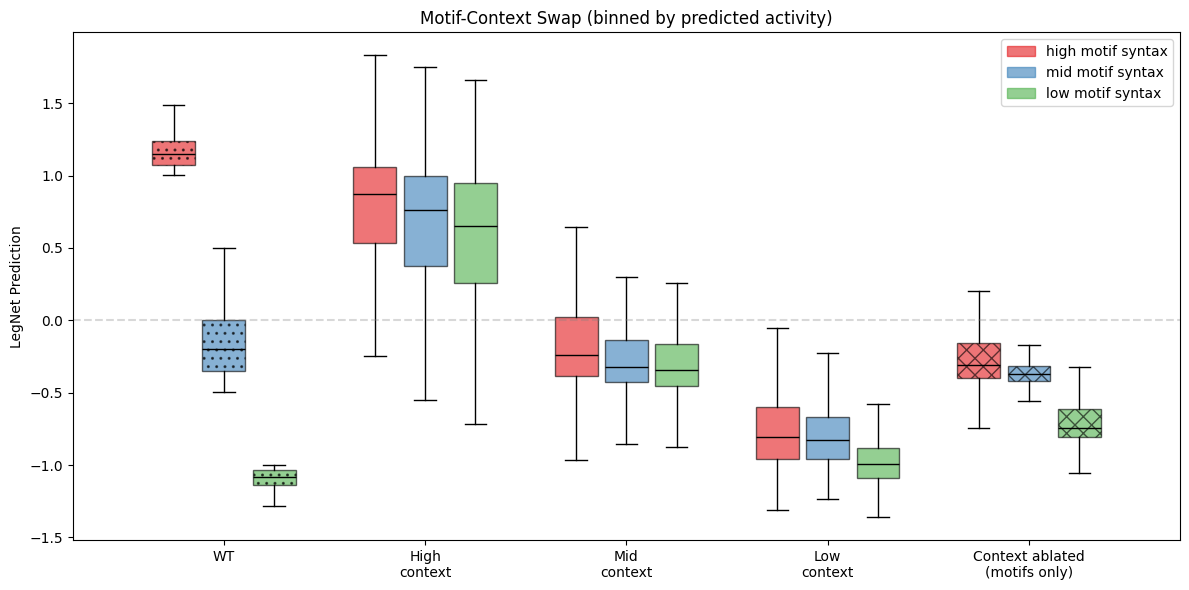

In [14]:
"""Cell 5: Re-bin by predicted activity, then plot."""
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BINS = ['high', 'mid', 'low']
BIN_COLORS = {'high': '#e41a1c', 'mid': '#377eb8', 'low': '#4daf4a'}

# Re-bin annotated sequences by predicted activity: high >1, mid (-0.5, 0.5), low <-1
pred_bin_map = {}
for sid in annotated_ids:
    p = seq_data[sid]['wt_pred']
    if p > 1:
        pred_bin_map[sid] = 'high'
    elif -0.5 <= p <= 0.5:
        pred_bin_map[sid] = 'mid'
    elif p < -1:
        pred_bin_map[sid] = 'low'

binned_ids = [sid for sid in annotated_ids if sid in pred_bin_map]
for b in BINS:
    sids = [sid for sid in binned_ids if pred_bin_map[sid] == b]
    preds = [seq_data[sid]['wt_pred'] for sid in sids]
    print(f'{b}: n={len(sids)}, pred range=[{min(preds):.3f}, {max(preds):.3f}]')
print(f'Excluded (in gap): {len(annotated_ids) - len(binned_ids)}')

# Re-bin chimera predictions using already-computed per-pair means.
chimera_preds_rebinned = {}
for (orig_db, orig_rb), pair_means in chimera_preds.items():
    if len(pair_means) == 0:
        continue
    donor_ids = sampled_seqs[orig_db]
    recip_ids = sampled_seqs[orig_rb]

    pair_idx = 0
    for donor_id in donor_ids:
        for recip_id in recip_ids:
            if donor_id == recip_id:
                continue
            if donor_id in pred_bin_map and recip_id in pred_bin_map:
                pred_db = pred_bin_map[donor_id]
                pred_rb = pred_bin_map[recip_id]
                key = (pred_db, pred_rb)
                chimera_preds_rebinned.setdefault(key, []).append(pair_means[pair_idx])
            pair_idx += 1

for key in sorted(chimera_preds_rebinned):
    arr = np.array(chimera_preds_rebinned[key], dtype=np.float32)
    chimera_preds_rebinned[key] = arr
    print(f'  rebinned ({key[0]}, {key[1]}): {len(arr)} pairs, mean={arr.mean():.4f}')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x_labels = ['WT', 'High\ncontext', 'Mid\ncontext', 'Low\ncontext',
            'Context ablated\n(motifs only)']
n_conditions = len(x_labels)
WT_IDX = 0
CA_IDX = 4

width = 0.25
offsets = {'high': -width, 'mid': 0, 'low': width}

for motif_bin in BINS:
    data_per_condition = []

    sids = [sid for sid in binned_ids if pred_bin_map[sid] == motif_bin]

    # WT
    data_per_condition.append([seq_data[sid]['wt_pred'] for sid in sids])

    # Chimeras by context bin
    for ctx_bin in BINS:
        key = (motif_bin, ctx_bin)
        if key in chimera_preds_rebinned and len(chimera_preds_rebinned[key]) > 0:
            data_per_condition.append(chimera_preds_rebinned[key].tolist())
        else:
            data_per_condition.append([])

    # Context-ablated
    data_per_condition.append([seq_data[sid]['context_ablated_pred'] for sid in sids])

    positions = [i + offsets[motif_bin] for i in range(n_conditions)]
    bp = ax.boxplot(data_per_condition, positions=positions, widths=width * 0.85,
                    patch_artist=True, showfliers=False, medianprops=dict(color='black'))
    for ci, patch in enumerate(bp['boxes']):
        patch.set_facecolor(BIN_COLORS[motif_bin])
        patch.set_alpha(0.6)
        if ci == WT_IDX:
            patch.set_hatch('..')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)
        elif ci == CA_IDX:
            patch.set_hatch('xx')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)

ax.set_xticks(range(n_conditions))
ax.set_xticklabels(x_labels)
ax.set_ylabel('LegNet Prediction')
ax.set_title('Motif-Context Swap (binned by predicted activity)')

handles = [mpatches.Patch(color=BIN_COLORS[b], alpha=0.6, label=f'{b} motif syntax') for b in BINS]
ax.legend(handles=handles, loc='upper right')
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.3)

fig.tight_layout()

fig.savefig(f'{MCS_DIR}/human_motif_context_swap_plot_K562.png', dpi=150, bbox_inches='tight')
print(f'Saved: {MCS_DIR}/human_motif_context_swap_plot_K562.png')